
# Diffusion MRI Simulators: Hands-on Tutorial

Walk through DMRI's simulator API: build acquisition schemes, simulate single-compartment models (Ball/Stick), and mix them into multi-compartment signals.


In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dmri.simulators import Ball, MultiCompartment, Stick
from dmri.simulators.acquisition_scheme import acquisition_scheme


## 1. Build an acquisition scheme

`acquisition_scheme` bundles **b-values** (diffusion weighting) and **b-vectors** (gradient directions). We sample 100 directions on a unit sphere and linearly spaced b-values up to 3000 s/mm².


In [3]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = jax.random.normal(jax.random.key(0), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals, bvecs)
acq

acquisition_scheme(bvals=Array([   0.     ,   30.30303,   60.60606,   90.90909,  121.21212,
        151.51515,  181.81818,  212.12122,  242.42424,  272.72726,
        303.0303 ,  333.33334,  363.63635,  393.9394 ,  424.24243,
        454.54544,  484.84848,  515.1515 ,  545.4545 ,  575.75757,
        606.0606 ,  636.36365,  666.6667 ,  696.96967,  727.2727 ,
        757.57574,  787.8788 ,  818.1818 ,  848.48486,  878.78784,
        909.0909 ,  939.3939 ,  969.69696, 1000.     , 1030.303  ,
       1060.6061 , 1090.909  , 1121.2122 , 1151.5151 , 1181.8181 ,
       1212.1212 , 1242.4242 , 1272.7273 , 1303.0303 , 1333.3334 ,
       1363.6364 , 1393.9393 , 1424.2424 , 1454.5454 , 1484.8485 ,
       1515.1515 , 1545.4546 , 1575.7576 , 1606.0605 , 1636.3636 ,
       1666.6666 , 1696.9697 , 1727.2727 , 1757.5757 , 1787.8788 ,
       1818.1818 , 1848.4849 , 1878.7878 , 1909.091  , 1939.3939 ,
       1969.6969 , 2000.     , 2030.303  , 2060.606  , 2090.9092 ,
       2121.2122 , 2151.5151 , 2181.8


## 2. Single-compartment examples

### Ball: isotropic diffusion
The Ball model represents free water with scalar diffusivity \(\lambda\).


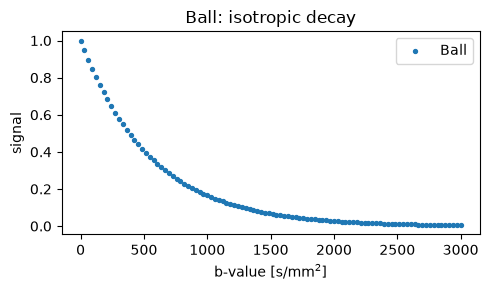

In [4]:
lam = 0.0018  # mm^2/s
ball = Ball(lam)
ball_signal = ball.signal(acq)
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(bvals, ball_signal, s=8, label="Ball")
ax.set(xlabel="b-value [s/mm$^2$]", ylabel="signal", title="Ball: isotropic decay")
ax.legend()
fig.tight_layout()


### Stick: orientation dependence
The Stick has zero radius and attenuates based on the projection of the gradient onto its orientation \(\boldsymbol{\mu}\).


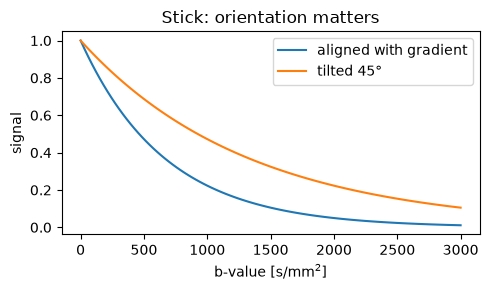

In [5]:
# Orientation only shows up against a *fixed* gradient direction. With the
# random bvecs above, every point samples a different angle and the effect
# smears into a band, so build a single-direction scheme to see it cleanly.
acq_z = acquisition_scheme(bvals, jnp.tile(jnp.array([0.0, 0.0, 1.0]), (100, 1)))

stick_aligned = Stick(jnp.array([0.0, 0.0]), lam_par=0.0015)
stick_tilted = Stick(jnp.array([jnp.pi / 4, 0.0]), lam_par=0.0015)

signal_aligned = stick_aligned.signal(acq_z)
signal_tilted = stick_tilted.signal(acq_z)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(bvals, signal_aligned, label="aligned with gradient")
ax.plot(bvals, signal_tilted, label="tilted 45$\\degree$")
ax.set(xlabel="b-value [s/mm$^2$]", ylabel="signal", title="Stick: orientation matters")
ax.legend()
fig.tight_layout()


## 3. Multi-compartment mixture

Combine compartments by subclassing `MultiCompartment`. Here we mix Ball + Stick with a uniform Dirichlet prior over fractions.

Noise compartments can be added separately to generate realistic magnitude observations.


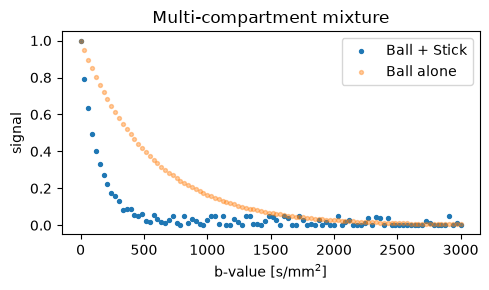

In [6]:
class BallStick(MultiCompartment):
    model_types = [Ball, Stick]
    noise_types = []
    fraction_prior = jnp.ones(2)


theta = jax.random.normal(jax.random.key(123), (BallStick.theta_dim,))
model = BallStick.from_theta(theta)
signal_mix = model.signal(acq)
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(bvals, signal_mix, s=8, label="Ball + Stick")
ax.scatter(bvals, ball_signal, s=8, alpha=0.4, label="Ball alone")
ax.set(xlabel="b-value [s/mm$^2$]", ylabel="signal", title="Multi-compartment mixture")
ax.legend()
fig.tight_layout()


## 4. Next steps
- Swap in `Sphere` or `Cylinder` to explore restricted diffusion.
- Add noise compartments (e.g., `BoundedGaussianNoise`) when simulating magnitude data.
- Use `model_mask` in `MultiCompartment.from_theta` to toggle components without changing the parameter layout.

For a deeper API tour, see the [simulator guide](../guides/simulators.md).
